In [0]:
# ---------------------------------------------------------------
# BLOQUE 1 — Carga y primera mirada
# ---------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Cargamos el Superstore como base de demostración.
# En la Parte 2 van a reemplazar esto con su propio dataset.
pdf = pd.read_csv("/Volumes/workspace/predicitibilidad_diagnostico/proyecto/Global Superstore.csv")

df = pdf.copy()

print(f"Filas: {df.shape[0]:,}   Columnas: {df.shape[1]}")
print("\nColumnas disponibles:")
print(df.columns.tolist())

Filas: 51,290   Columnas: 27

Columnas disponibles:
['Category', 'City', 'Country', 'Customer ID', 'Customer Name', 'Discount', 'Market', 'ji_lu-shu', 'Order Date', 'Order ID', 'Order Priority', 'Product ID', 'Product Name', 'Profit', 'Quantity', 'Region', 'Row ID', 'Sales', 'Segment', 'Ship Date', 'Ship Mode', 'Shipping Cost', 'State', 'Sub-Category', 'Year', 'Market2', 'weeknum']


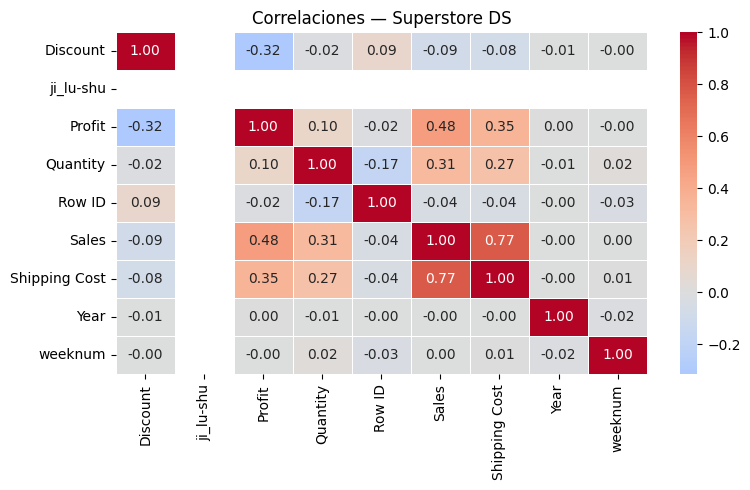

In [0]:
# ---------------------------------------------------------------
# BLOQUE 5 — Correlación entre variables
# ---------------------------------------------------------------
# La correlación mide qué tan relacionadas están dos variables.
# Rango: -1 (inversa perfecta) a +1 (directa perfecta).
# 0 = sin relación lineal.
#
# En el Módulo 3 usaron esto para seleccionar variables.
# Hoy entienden por qué ese criterio tiene sentido estadístico.

corr = df.select_dtypes(include='number').corr()

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlaciones — Superstore DS')
plt.tight_layout()
plt.show()

# Hallazgos clave:
# Sales  - Profit:   r ≈ +0.48 → positiva moderada
# Discount - Profit: r ≈ -0.22 → negativa débil (más descuento, menos ganancia)
# Discount - Sales:  r ≈ -0.03 → prácticamente nula


In [0]:
# ---------------------------------------------------------------
# BLOQUE 6 — Prueba de hipótesis: ¿la diferencia es real?
# ---------------------------------------------------------------
# H0: no hay diferencia entre grupos (lo que asumimos por defecto)
# H1: sí hay diferencia real (lo que queremos demostrar)
#
# El valor p: si p < 0.05 → rechazamos H0 → diferencia probablemente real.
# IMPORTANTE: p < 0.05 no dice que la diferencia sea grande o importante.

g1 = df[df['Category'] == 'Technology']['Profit']
g2 = df[df['Category'] == 'Furniture']['Profit']

t_stat, p_val = stats.ttest_ind(g1, g2)

print("Prueba t — Technology vs Furniture (Profit)")
print(f"  Media Technology: ${g1.mean():.2f}")
print(f"  Media Furniture:  ${g2.mean():.2f}")
print(f"  Diferencia:       ${g1.mean() - g2.mean():.2f}")
print(f"  Valor p:          {p_val:.4f}")
if p_val < 0.05:
    print("  → Diferencia estadísticamente significativa.")
else:
    print("  → No hay evidencia suficiente de diferencia.")


Prueba t — Technology vs Furniture (Profit)
  Media Technology: $65.45
  Media Furniture:  $28.88
  Diferencia:       $36.58
  Valor p:          0.0000
  → Diferencia estadísticamente significativa.


In [0]:
# ---------------------------------------------------------------
# BLOQUE A — Cargar su dataset
# ---------------------------------------------------------------
# Reemplacen esto con la carga de su propio dataset.
# Si lo tienen en Databricks:
#   mi_df = spark.table("workspace.default.SU_TABLA").toPandas()
# Si lo tienen como CSV:
#   mi_df = pd.read_csv("/ruta/a/su/archivo.csv")

# Ejemplo genérico — cambien por su dataset real:
mi_df = pd.read_csv("/Volumes/workspace/predicitibilidad_diagnostico/proyecto/Global Superstore.csv")
# o:
# mi_df = pd.read_csv("/dbfs/FileStore/su_archivo.csv")

print(f"Dataset: {mi_df.shape[0]:,} filas, {mi_df.shape[1]} columnas")
print("\nmi_df.shape:")
print(mi_df.shape)
print("\nmi_df.dtypes:")
print(mi_df.dtypes)
print("\nPorcentaje de nulos por columna:")
print(mi_df.isna().mean().sort_values(ascending=False) * 100)
print("\nFilas duplicadas:")
print(mi_df.duplicated().sum())
print("\nValores únicos por columna:")
print(mi_df.nunique().sort_values(ascending=False))
print("\nColumnas:")
print(mi_df.columns.tolist())
print("\nPrimeras filas:")
mi_df.head()

Dataset: 51,290 filas, 27 columnas

mi_df.shape:
(51290, 27)

mi_df.dtypes:
Category           object
City               object
Country            object
Customer ID        object
Customer Name      object
Discount          float64
Market             object
ji_lu-shu           int64
Order Date         object
Order ID           object
Order Priority     object
Product ID         object
Product Name       object
Profit            float64
Quantity            int64
Region             object
Row ID              int64
Sales               int64
Segment            object
Ship Date          object
Ship Mode          object
Shipping Cost     float64
State              object
Sub-Category       object
Year                int64
Market2            object
weeknum             int64
dtype: object

Porcentaje de nulos por columna:
Category          0.0
Quantity          0.0
Market2           0.0
Year              0.0
Sub-Category      0.0
State             0.0
Shipping Cost     0.0
Ship Mode         0.

,Category,City,Country,Customer ID,Customer Name,Discount,Market,ji_lu-shu,Order Date,Order ID,Order Priority,Product ID,Product Name,Profit,Quantity,Region,Row ID,Sales,Segment,Ship Date,Ship Mode,Shipping Cost,State,Sub-Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,High,OFF-PA-10002005,Xerox 225,9.3312,3,West,36624,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,Medium,OFF-PA-10002893,"Wirebound Service Call Books, 5 1/2"" x 4""",9.2928,2,West,37033,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,Medium,OFF-PA-10000659,"Adams Phone Message Book, Professional, 400 Me...",9.8418,3,West,31468,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,Medium,OFF-PA-10001144,Xerox 1913,53.2608,2,West,31469,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,00:00.0,CA-2011-146969,High,OFF-PA-10002105,Xerox 223,3.1104,1,West,32440,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


In [0]:
# ---------------------------------------------------------------
# BLOQUE B — Estadística descriptiva de su dataset
# ---------------------------------------------------------------

# Resumen general
print("=== Resumen estadístico ===")
print(mi_df.describe().round(2))

# Identifiquen sus columnas numéricas clave
# (las que son relevantes para su problema de negocio)
COLUMNA_OBJETIVO = "Profit"   # cambia esto si tu variable objetivo es otra

print(f"\n=== Análisis de {COLUMNA_OBJETIVO} ===")
print(f"Media:    {mi_df[COLUMNA_OBJETIVO].mean():.2f}")
print(f"Mediana:  {mi_df[COLUMNA_OBJETIVO].median():.2f}")
print(f"Std:      {mi_df[COLUMNA_OBJETIVO].std():.2f}")
print(f"Sesgo:    {mi_df[COLUMNA_OBJETIVO].skew():.2f}")

=== Resumen estadístico ===
       Discount  ji_lu-shu    Profit  ...  Shipping Cost      Year   weeknum
count  51290.00    51290.0  51290.00  ...       51290.00  51290.00  51290.00
mean       0.14        1.0     28.61  ...          26.38   2012.78     31.29
std        0.21        0.0    174.34  ...          57.30      1.10     14.43
min        0.00        1.0  -6599.98  ...           0.00   2011.00      1.00
25%        0.00        1.0      0.00  ...           2.61   2012.00     20.00
50%        0.00        1.0      9.24  ...           7.79   2013.00     33.00
75%        0.20        1.0     36.81  ...          24.45   2014.00     44.00
max        0.85        1.0   8399.98  ...         933.57   2014.00     53.00

[8 rows x 9 columns]

=== Análisis de Profit ===
Media:    28.61
Mediana:  9.24
Std:      174.34
Sesgo:    4.16


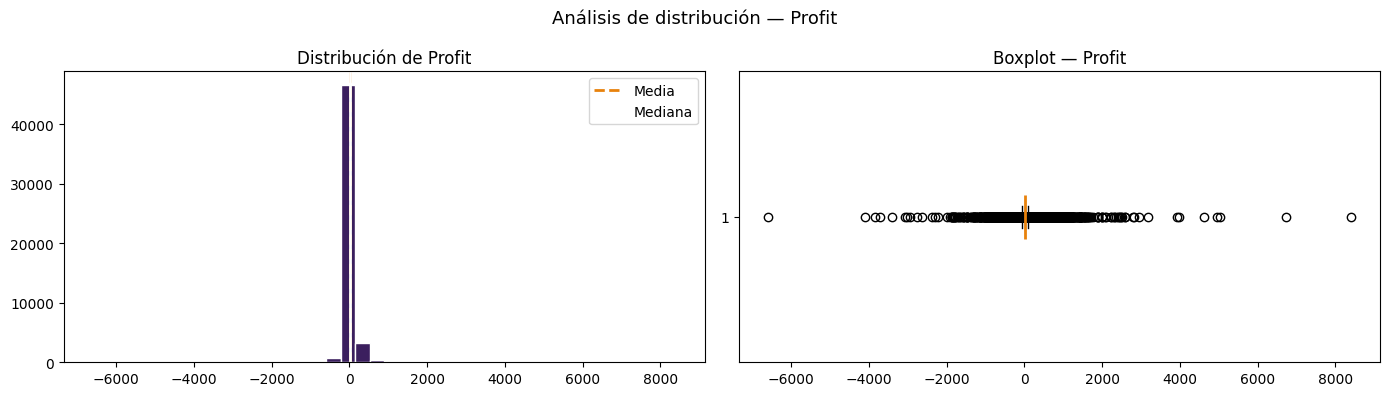

In [0]:
# ---------------------------------------------------------------
# BLOQUE C — Distribución de la variable principal
# ---------------------------------------------------------------
# Grafiquen la distribución de su variable más importante.

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(mi_df[COLUMNA_OBJETIVO].dropna(), bins=40, color='#3B1F5E', edgecolor='white')
axes[0].axvline(mi_df[COLUMNA_OBJETIVO].mean(),   color='#E8820C', lw=2, ls='--', label='Media')
axes[0].axvline(mi_df[COLUMNA_OBJETIVO].median(), color='white',   lw=2, ls='-',  label='Mediana')
axes[0].set_title(f'Distribución de {COLUMNA_OBJETIVO}')
axes[0].legend()

# Boxplot para visualizar outliers
axes[1].boxplot(mi_df[COLUMNA_OBJETIVO].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='#3B1F5E', color='white'),
                medianprops=dict(color='#E8820C', linewidth=2))
axes[1].set_title(f'Boxplot — {COLUMNA_OBJETIVO}')

plt.suptitle(f'Análisis de distribución — {COLUMNA_OBJETIVO}', fontsize=13)
plt.tight_layout()
plt.show()


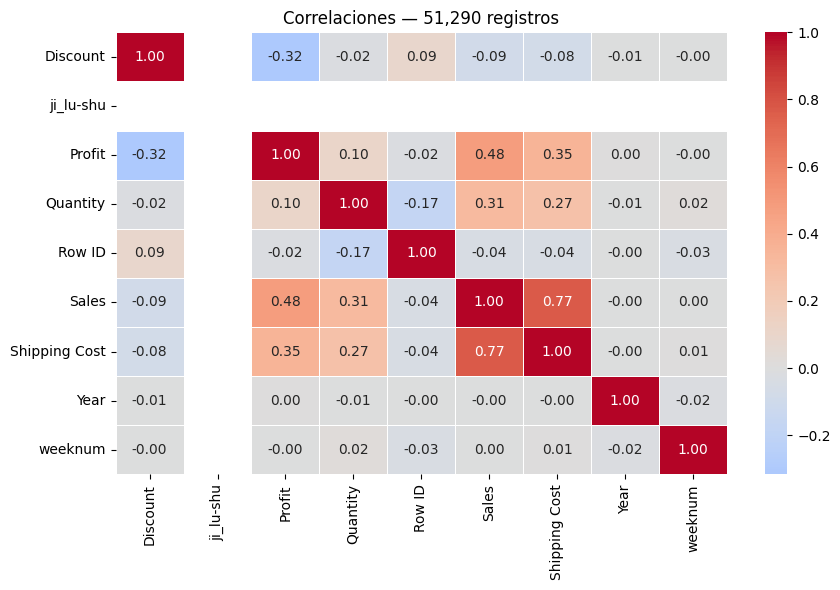


Correlación con Profit:
Sales            0.485
Shipping Cost    0.354
Discount        -0.316
Quantity         0.104
Row ID          -0.019
Year             0.003
weeknum         -0.000
ji_lu-shu          NaN
Name: Profit, dtype: float64


In [0]:
# ---------------------------------------------------------------
# BLOQUE D — Correlaciones en su dataset
# ---------------------------------------------------------------
# ¿Qué variables numéricas están relacionadas entre sí?
# ¿Cuál tiene mayor relación con su variable objetivo?

numericas = mi_df.select_dtypes(include='number')

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(numericas.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title(f'Correlaciones — {mi_df.shape[0]:,} registros')
plt.tight_layout()
plt.show()

# Tabla de correlación con la variable objetivo
print(f"\nCorrelación con {COLUMNA_OBJETIVO}:")
corr_obj = numericas.corr()[COLUMNA_OBJETIVO].drop(COLUMNA_OBJETIVO)
print(corr_obj.sort_values(key=abs, ascending=False).round(3))


=== Profit por Category ===
                  mean  median     std  count
Category                                     
Furniture        28.88   15.50  205.76   9876
Office Supplies  16.58    6.55  109.75  31273
Technology       65.45   29.94  271.22  10141


/home/spark-19620ef6-7474-44d3-8576-af/.ipykernel/2052/command-4723536642226239-884577953:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grupos, labels=etiquetas, patch_artist=True)


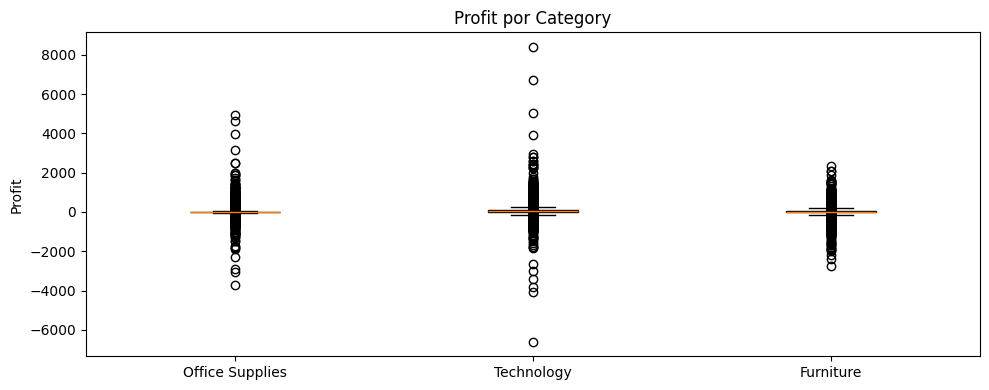

In [0]:
# ---------------------------------------------------------------
# BLOQUE E — Análisis por segmento (si aplica)
# ---------------------------------------------------------------
# Si su dataset tiene una columna categórica relevante
# (tipo de cliente, categoría de producto, región, etc.)
# úsenla para ver si el comportamiento cambia entre grupos.

COLUMNA_SEGMENTO = "Category"   # cambia esto

print(f"=== {COLUMNA_OBJETIVO} por {COLUMNA_SEGMENTO} ===")
print(mi_df.groupby(COLUMNA_SEGMENTO)[COLUMNA_OBJETIVO]
      .agg(['mean', 'median', 'std', 'count'])
      .round(2))

# Visualización comparativa
fig, ax = plt.subplots(figsize=(10, 4))
grupos = [mi_df[mi_df[COLUMNA_SEGMENTO] == g][COLUMNA_OBJETIVO].dropna()
          for g in mi_df[COLUMNA_SEGMENTO].unique()]
etiquetas = mi_df[COLUMNA_SEGMENTO].unique().tolist()
ax.boxplot(grupos, labels=etiquetas, patch_artist=True)
ax.set_title(f'{COLUMNA_OBJETIVO} por {COLUMNA_SEGMENTO}')
ax.set_ylabel(COLUMNA_OBJETIVO)
plt.tight_layout()
plt.show()




In [0]:
# ---------------------------------------------------------------
# BLOQUE F — Prueba de hipótesis sobre sus datos
# ---------------------------------------------------------------
# Elijan dos grupos de su dataset y prueben si la diferencia
# en la variable objetivo es estadísticamente significativa.
#
# Ejemplo: ¿el grupo A tiene un valor promedio diferente al grupo B?

GRUPO_A = "NOMBRE_GRUPO_A"   # cambia esto
GRUPO_B = "NOMBRE_GRUPO_B"   # cambia esto

datos_A = mi_df[mi_df[COLUMNA_SEGMENTO] == GRUPO_A][COLUMNA_OBJETIVO].dropna()
datos_B = mi_df[mi_df[COLUMNA_SEGMENTO] == GRUPO_B][COLUMNA_OBJETIVO].dropna()

t_stat, p_val = stats.ttest_ind(datos_A, datos_B)

print(f"Prueba t — {GRUPO_A} vs {GRUPO_B}")
print(f"  Media {GRUPO_A}: {datos_A.mean():.2f}")
print(f"  Media {GRUPO_B}: {datos_B.mean():.2f}")
print(f"  Diferencia:      {datos_A.mean() - datos_B.mean():.2f}")
print(f"  Valor p:         {p_val:.4f}")
print()
if p_val < 0.05:
    print("  → Diferencia estadísticamente significativa (p < 0.05).")
    print("  → Ahora la pregunta importante: ¿es relevante para su negocio?")
else:
    print("  → No hay evidencia suficiente de diferencia real.")
    print("  → Eso también es información: los grupos se comportan igual.")


Prueba t — NOMBRE_GRUPO_A vs NOMBRE_GRUPO_B
  Media NOMBRE_GRUPO_A: nan
  Media NOMBRE_GRUPO_B: nan
  Diferencia:      nan
  Valor p:         nan

  → No hay evidencia suficiente de diferencia real.
  → Eso también es información: los grupos se comportan igual.


/databricks/python/lib/python3.12/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
